# Real Earnings Management — a quantitative teardown 🔬
### Roychowdhury's two normal-level residuals · a point-in-time calendar-time tercile long-short (Newey-West) · sign-instability across staleness & eras · a pooled event-drift cross-check with a two-sided label-shuffle placebo · the gross-margin-reversal regression · a 12-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Operating reversal%3F: Not detected](https://img.shields.io/badge/Operating_reversal%3F-Not_detected-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a **Roychowdhury (2006) REM proxy** (abnormally high production + abnormally low discretionary expense) **predicts forward returns** — resolves into a clean null that isn't even sign-stable. This is distinct from every sibling on the desk: [574](../../574-penny-beat/) documents the *just-beat* discontinuity, [229](../../229-beneish-m-score/) and [855](../../855-accrual-quality/) detect *accrual* manipulation, [525](../../525-r-and-d-intensity/) ranks the R&D *level*. This is the **real-activity** residual.

> ⚠️ **Data note.** EDGAR `Revenues`/`CostOfRevenue`/`SG&A`/`R&D` (flows) + `InventoryNet`/`Assets` (instants) + yfinance closes, 32 usable names, ends 2009-07-31 → 2026-03-31, as-of 2026-06-30. Point-in-time on the **filing date**. Survivorship named on the Signal axis (current-survivors basket). Thin/uneven coverage + pooled-industry, in-sample benchmark are first-class caveats. Numbers in [`docs/results.md`](../docs/results.md) (prices fingerprint `e443c0a5d730`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from real_earn_mgmt import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 32, 'n_roster': 44, 'n_events': 630, 'end_lo': '2009-07-31', 'end_hi': '2026-03-31', 'fp_prices': 'e443c0a5d730', 'n_months': 153, 'avg_n': 17.1, 'ls_span_lo': '2009-11-30', 'ls_span_hi': '2026-03-31', 'ls_mean_bps': -9.2, 'ls_ann': -1.1, 'ls_t_iid': -0.21, 'ls_t_nw': -0.16, 'ls_sharpe': -0.06, 'ls_hit': 46, 'ls_long_bps': 179.6, 'ls_short_bps': 188.8, 'ls_turn': 0.16, 'ls120_mean_bps': 75.3, 'ls120_t_nw': 1.82, 'abprod_mean_bps': -5.5, 'abprod_t_nw': -0.09, 'abdisx_mean_bps': 30.7, 'abdisx_t_nw': 0.69, 'drift': {21: (630, 1.7, 1.26, 0.44, 0.63, 46, 0.5308), 63: (629, 4.65, 5.52, -0.87, -0.62, 47, 0.4903), 126: (628, 10.16, 10.45, -0.28, -0.14, 45, 0.8796)}, 'mono63': (5.52, 3.39, 4.65), 'era_early_n': 62, 'era_early_bps': 69.5, 'era_early_t': 1.02, 'era_late_n': 91, 'era_late_bps': -62.8, 'era_late_t': -0.79, 'op_n': 339, 'op_slope': 0.0569, 'op_t': 1.36, 'op_r2': 0.005, 'op_corr': 0.074, 'op_top_dgm': 0.56, 'op_bot_dgm': 0.08, 'op_spread': 0.48, 'net': {(10, 50): (-9.0, -1.08, -0.16, -0.06), (20, 100): (-8.8, -1.05, -0.16, -0.06)}, 'syn_null_mean': 0.31, 'syn_null_sd': 0.78, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 874.2, 'syn_planted_t': 20.28}


real cache present: True | events: 630 | names: 32


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `NONE` | calendar tercile long-short **-9.2 bps/mo** (-1.1%/yr gross), one-sample *t* = -0.21, **Newey-West *t* = -0.16**; sign flips to +75 bps at staleness 120 and across the 2015 era split |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: NW *t* = -0.16, Sharpe -0.06; a zero gross edge |
| **Operating reversal?** | `NOT DETECTED` | forward Δ gross-margin on REM: slope +0.057 (*t* +1.36, R² 0.005), wrong-signed vs the reversal prediction |

> 💡 In plain words: a beautiful forensic construct that neither sorts returns nor, on this pooled panel, shows its own operating footprint. A public residual the market has no need to misprice.

## 1 · The claim, formalised

Scale everything by lagged assets $A_{t-1}$. Roychowdhury's two normal-level models, fit cross-sectionally:

$$\frac{DISX_t}{A_{t-1}} = a_0 + a_1\frac{1}{A_{t-1}} + a_2\frac{Sales_{t-1}}{A_{t-1}} + \varepsilon^{DISX}_t,\qquad DISX = R\&D + SG\&A$$

$$\frac{PROD_t}{A_{t-1}} = a_0 + a_1\frac{1}{A_{t-1}} + a_2\frac{Sales_t}{A_{t-1}} + a_3\frac{\Delta Sales_t}{A_{t-1}} + a_4\frac{\Delta Sales_{t-1}}{A_{t-1}} + \varepsilon^{PROD}_t,\qquad PROD = COGS + \Delta Inv$$

The abnormal pieces are the residuals; $\text{REM} = \varepsilon^{PROD} - \varepsilon^{DISX}$ (overproduce **and** cut discretionary ⇒ high REM). The claims:

- **H₁ (leads returns).** A cross-sectional long-short on REM earns a forward spread (the mispricing claim; the literature's sign is *negative* — manipulators under-perform).
- **H₂ (operating reversal).** High REM foreshadows a **drop** in next-quarter gross margin (overproduction give-back).
- **H₃ (tradable).** Any spread survives realistic long-short costs + borrow.

We find **H₁ a flat null** (NW *t* = -0.16, sign-unstable), **H₂ not detected** (slope +0.057, wrong-signed, *t* +1.36), and therefore **H₃ moot**. The DGP the sort would need is simply not in this tape.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, because the signal is persistent and filings cluster: a monthly long-short series lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** (not quintiles) and require ≥ 6 names. Crucially we also probe **sign-stability** — a real edge keeps its sign when the staleness window or the sample split changes; noise doesn't. The pooled event drift + a **two-sided** label-shuffle placebo is the cross-check (two-sided because the sign is a hypothesis); the gross-margin-reversal regression is the mechanism axis, read on magnitude (its pooled *t* ignores quarter clustering).

## 3 · How we'd know — the protocol

- **Panel.** 630 (ticker, filing) firm-quarters across 32 usable names (of 44 in the roster), ends 2009-07-31 → 2026-03-31, each stamped with its 10-Q/10-K filing date (point-in-time).
- **Signal.** Pooled OLS residuals of the two normal-level models → `ab_prod`, `ab_disx`; `rem = ab_prod − ab_disx`.
- **Primary.** Monthly tercile long-short on `rem`, one execution lag; Newey-West + one-sample *t*, Sharpe, hit rate.
- **Robustness.** Staleness 120 vs 200 d; the two components separately; an era split at 2015.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, top-minus-bottom tercile, one-sample *t* + two-sided label-shuffle placebo, and the tercile monotonicity.
- **Mechanism.** Pooled OLS of the forward gross-margin change on `rem`.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic panel, planted-lead knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh REM signals into terciles each month, long top / short bottom equal-weight, earn next month's return. The decisive statistic is the HAC *t* of the monthly series.

calendar long-short: -9.2 bps/mo (-1.10%/yr gross), n=153 months, avg cross-section 17.1
  one-sample t = -0.21   Newey-West(6) t = -0.16   Sharpe -0.06   hit 46%   turnover 0.16
  component ab_prod: -5.5 bps, NW t = -0.09  |  ab_disx: +30.7 bps, NW t = +0.69


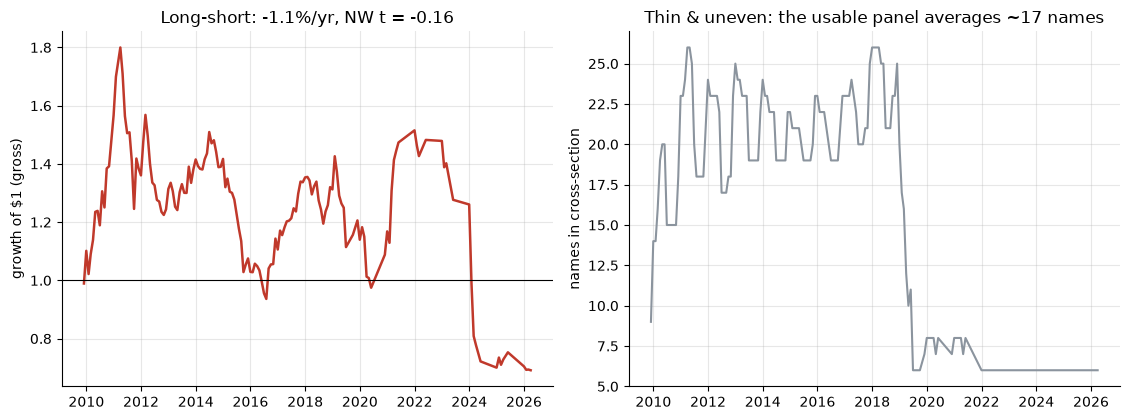

frozen: -9.2 bps/mo, NW t = -0.16; ab_prod NW t = -0.09, ab_disx NW t = +0.69


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='rem', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    lsp = st.calendar_ls(PX, EV, signal_col='ab_prod', staleness_days=200); sp = st.calendar_ls_stats(lsp)
    lsd = st.calendar_ls(PX, EV, signal_col='ab_disx', staleness_days=200); sd = st.calendar_ls_stats(lsd)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo ({s['ann_pct']:+.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  component ab_prod: {sp['mean_bps']:+.1f} bps, NW t = {sp['t_nw']:+.2f}  |  "
          f"ab_disx: {sd['mean_bps']:+.1f} bps, NW t = {sd['t_nw']:+.2f}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=RED, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: {R['ls_ann']:+.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven: the usable panel averages ~17 names')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}; "
      f"ab_prod NW t = {R['abprod_t_nw']:+.2f}, ab_disx NW t = {R['abdisx_t_nw']:+.2f}")

> 💡 In plain words: **-9 bps/month** at HAC *t* = **-0.16** is a zero. And the two ingredients don't even agree — `ab_prod` alone is -5.5 bps (NW *t* = -0.09), `ab_disx` alone is +30.7 bps (NW *t* = +0.69). With n=153 months and an avg cross-section of 17, the sort carries no return information.

### 4b · Sign-instability — the giveaway

A real edge is stubborn about its sign. Recompute the same long-short with a shorter staleness window, and split it at 2015.

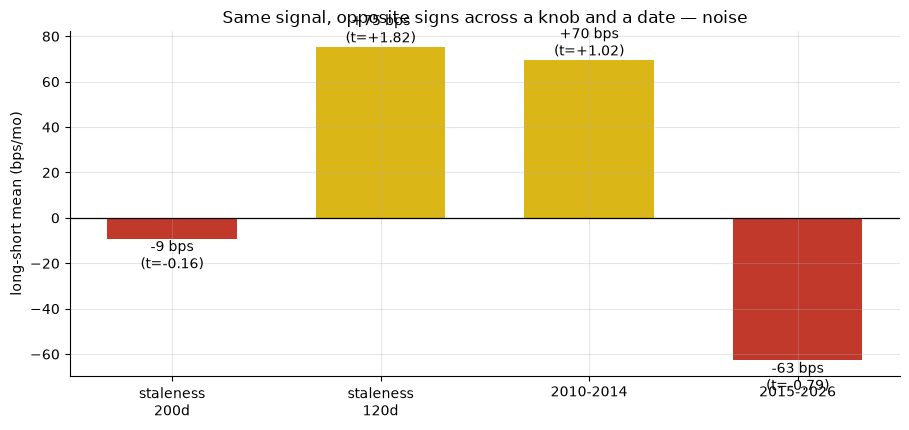

staleness/era cuts flip the sign; a live edge would not


In [3]:
labels = ['staleness\n200d','staleness\n120d','2010-2014','2015-2026']
if HAVE_REAL:
    ls200 = st.calendar_ls(PX, EV, signal_col='rem', staleness_days=200)
    ls120 = st.calendar_ls(PX, EV, signal_col='rem', staleness_days=120)
    b200, b120 = st.calendar_ls_stats(ls200)['mean_bps'], st.calendar_ls_stats(ls120)['mean_bps']
    e = ls200[ls200.index < '2015-01-01']['ls'].to_numpy(); l = ls200[ls200.index >= '2015-01-01']['ls'].to_numpy()
    vals = [b200, b120, e.mean()*1e4, l.mean()*1e4]
    ts   = [st.calendar_ls_stats(ls200)['t_nw'], st.calendar_ls_stats(ls120)['t_nw'], st.newey_west_t(e), st.newey_west_t(l)]
else:
    vals = [R['ls_mean_bps'], R['ls120_mean_bps'], R['era_early_bps'], R['era_late_bps']]
    ts   = [R['ls_t_nw'], R['ls120_t_nw'], R['era_early_t'], R['era_late_t']]
cols = [RED if v < 0 else AMBER for v in vals]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(labels, vals, color=cols, width=.62)
for i,(v,t_) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.0f} bps\n(t={t_:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.9); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Same signal, opposite signs across a knob and a date — noise')
plt.tight_layout(); plt.show()
print('staleness/era cuts flip the sign; a live edge would not')

> 💡 In plain words: -9 bps (staleness 200) becomes **+75** bps (staleness 120), and +70 bps pre-2015 becomes -63 bps post. None clears |2|. A signal whose sign is a coin-flip of the researcher's arbitrary choices is the textbook picture of **no effect** — this is what earns the `NONE`, not merely a sub-2 *t*.

### 4c · The cross-check — pooled event drift + two-sided placebo + monotonicity

Bucket all events by REM; top-minus-bottom forward drift with a two-sided label-shuffle null. A real sort would form a ladder.

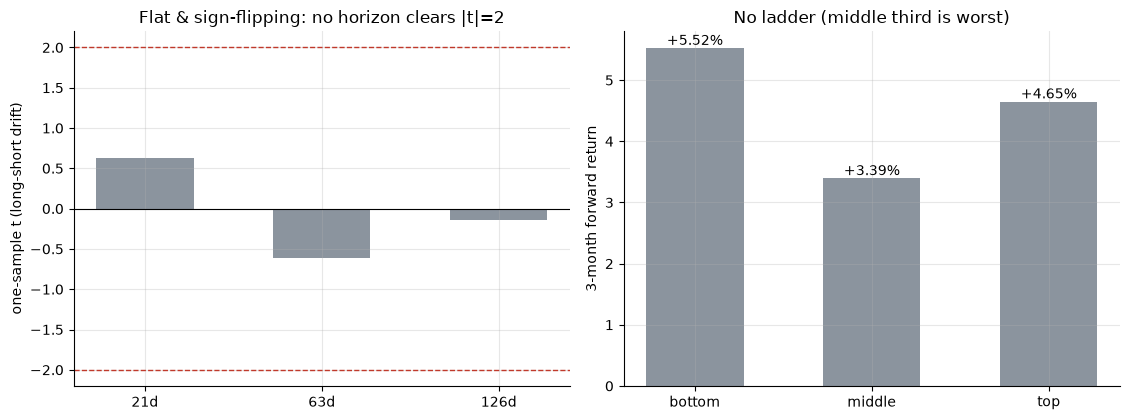

  H= 21d: long-short +0.44%  t=+0.63  win=46%  placebo p=0.539
  H= 63d: long-short -0.87%  t=-0.62  win=47%  placebo p=0.490
  H=126d: long-short -0.28%  t=-0.14  win=45%  placebo p=0.875


In [4]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=2000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Flat & sign-flipping: no horizon clears |t|=2')
a2.bar(['bottom','middle','top'], mono, color=GREY, width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('No ladder (middle third is worst)')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift **flips sign across horizons** (+0.44% at 21d, -0.87% at 63d), no *t* exceeds ±0.63, the two-sided placebo *p* sits at **0.49–0.88** (a random split matches the real one about half the time), and the terciles are **non-monotone** — the *middle* third (+3.39% at 63d) is the worst. The event study and the calendar long-short agree: no return sort.

### 4d · The mechanism — no gross-margin reversal either

Pooled OLS of the forward gross-margin change ($next\_gm - gm$) on REM, and the forward-Δgm spread between the top and bottom REM terciles. The value-destruction story predicts a **negative** slope.

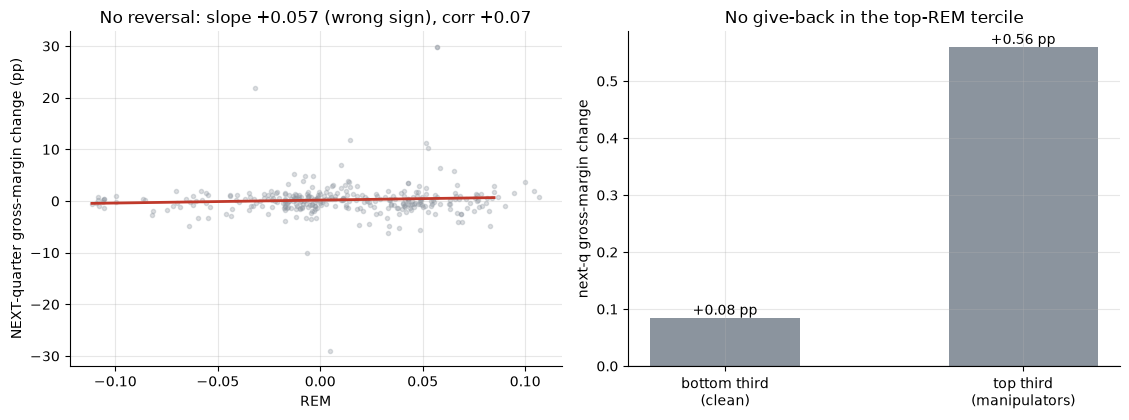

leads-operating: slope +0.0569, corr +0.074, forward-dgm spread +0.48 pp (top +0.56 vs bottom +0.08)


In [5]:
if HAVE_REAL:
    q = st.leads_operating(EV)
    fr = EV.dropna(subset=['rem','gm','next_gm'])
    x = fr['rem'].to_numpy(); y = (fr['next_gm']-fr['gm']).to_numpy()
    slope, corr, top, bot = q['slope'], q['corr'], q['top_dgm']*100, q['bot_dgm']*100
else:
    x = y = None
    slope, corr, top, bot = R['op_slope'], R['op_corr'], R['op_top_dgm'], R['op_bot_dgm']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if x is not None:
    m = (np.abs(x)<np.percentile(np.abs(x),98))&(np.abs(y)<0.3)
    a1.scatter(x[m], y[m]*100, s=9, alpha=.3, color=GREY)
    xs = np.linspace(np.percentile(x,2), np.percentile(x,98), 50)
    a1.plot(xs, (slope*xs + (y.mean()-slope*x.mean()))*100, color=RED, lw=2)
    a1.set_xlabel('REM'); a1.set_ylabel('NEXT-quarter gross-margin change (pp)')
    a1.set_title(f'No reversal: slope {slope:+.3f} (wrong sign), corr {corr:+.2f}')
else:
    a1.text(.5,.5,'run with cache',ha='center'); a1.set_axis_off()
a2.bar(['bottom third\n(clean)','top third\n(manipulators)'], [bot, top], color=[GREY, GREY], width=.5)
for i,v in enumerate([bot, top]): a2.annotate(f'{v:+.2f} pp',(i,v),ha='center',va='bottom')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('next-q gross-margin change'); a2.set_title('No give-back in the top-REM tercile')
plt.tight_layout(); plt.show()
print(f'leads-operating: slope {slope:+.4f}, corr {corr:+.3f}, forward-dgm spread {top-bot:+.2f} pp (top {top:+.2f} vs bottom {bot:+.2f})')

> 💡 In plain words: the operating footprint is **absent** here — slope +0.057 (*t* +1.36, R² 0.005), the **wrong sign** for a reversal, and a forward-Δgm spread of only +0.48 pp. Unlike a study where the mechanism holds but the market prices it, here neither the return sort nor the mechanism appears — consistent with the caveat that a *pooled-industry*, *in-sample* residual on ~17 names is a noisy proxy for Roychowdhury's industry-year construct. An honest non-detection, not a refutation.

### 4e · Tradability — the timer

For completeness, the calendar long-short net of one-way costs × turnover (both legs) + short borrow — though a zero gross edge already settles it.

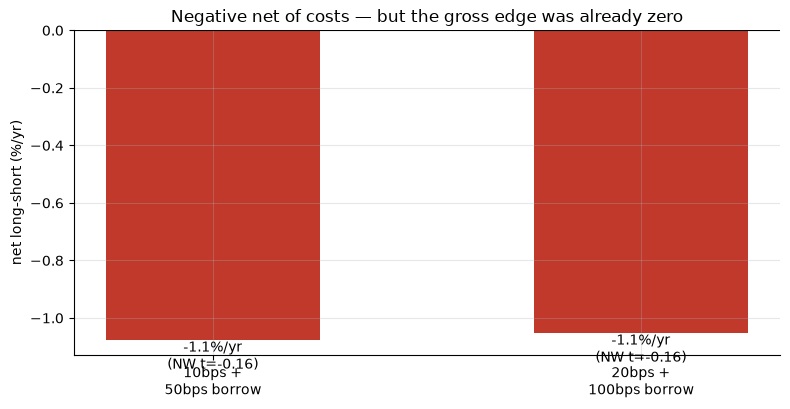

  cost 10bps + borrow 50bps/yr: -1.08%/yr net, NW t=-0.16, Sharpe -0.06
  cost 20bps + borrow 100bps/yr: -1.05%/yr net, NW t=-0.16, Sharpe -0.06


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[RED, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'{a:+.1f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Negative net of costs — but the gross edge was already zero')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: {a:+.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: net NW *t* = -0.16, Sharpe -0.06. There was nothing to cost — the gross edge is a (slightly negative) zero. **Tradability = MIRAGE.**

### 4f · Faithful-engine & power control

Synthetic price + REM-signal panel with a TUNABLE planted lead (high-REM names drift up). The null (edge = 0) is checked over **12 seeds**.

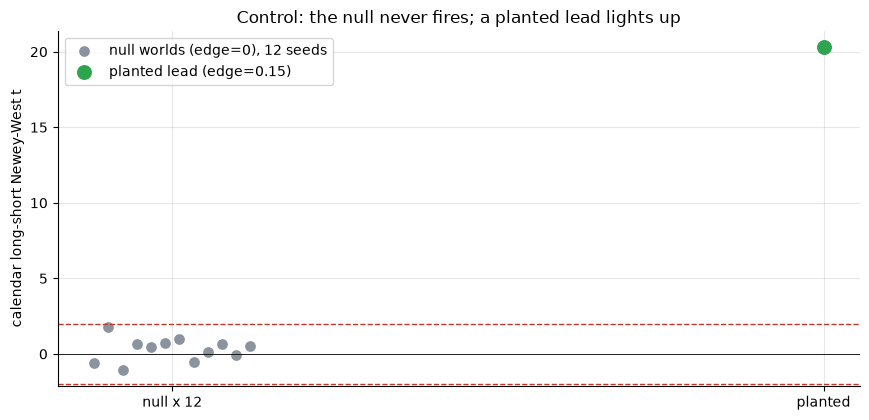

null: mean NW t = +0.31 (sd 0.78), |t|>=2 in 0/12  |  planted NW t = +20.28


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=862 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.15, seed=862)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted lead (edge=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null never fires; a planted lead lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = +0.31 (sd 0.78) and crosses |t|=2 0/12 times; a planted lead reads NW *t* = 20.3. The machinery is unbiased and powered, so the real-tape -0.16 is a genuine null, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `NONE`** — calendar tercile long-short -9.2 bps/mo (-1.1%/yr gross), one-sample *t* = -0.21, **Newey-West *t* = -0.16**; the sign **flips** across the staleness knob (+75 bps at 120 d) and the 2015 split (+70 / -63 bps); the pooled event drift is flat, sign-flipping and non-monotone (placebo *p* ≈ 0.5–0.9). No stable sign, no certification.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: -1.05%/yr, NW *t* = -0.16, Sharpe -0.06; a zero gross edge.
- **Operating reversal `NOT DETECTED`** — forward Δ gross-margin on REM: slope +0.057 (*t* +1.36, R² 0.005), wrong-signed and insignificant. On this pooled-industry panel the mechanism is not observable.

## 6 · Going further

- **The residual worth chasing** is Roychowdhury's original **industry-year** estimation (hundreds of names per bin, so the residual isn't industry-contaminated), and the population REM was designed for: firms that **just barely beat** the benchmark. A cleaner residual on a wider panel is the honest next step — the flat, sign-unstable result here is exactly what a noisy pooled proxy on ~17 names should produce under the null.
- **Coverage honesty:** only 32 of 44 names clear the usable bar (Q4 flow tags missing, several names never report R&D), the cross-section averages ≈17, and the benchmark coefficients are pooled in-sample across industries. Every number should be read in that light.
- **Dedup map:** [574-penny-beat](../../574-penny-beat/) (the *just-beat* discontinuity), [229-beneish-m-score](../../229-beneish-m-score/) and [855-accrual-quality](../../855-accrual-quality/) (the *accrual* channel), [525-r-and-d-intensity](../../525-r-and-d-intensity/) (the R&D *level*). None ranks on the Roychowdhury REM residual itself.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*